<a href="https://colab.research.google.com/github/donjadao/donjadao/blob/main/lab-7/dao_don_lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

importing libraries and vader_lexicon for sentiment analysis

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

loading data from lab 4 topic modeling, my data was from the imdb which is split between already positive and negative reviews, but we are going to get rid of those labels. My data is also not a csv but a single files of text per review

In [2]:

import requests

base_api = "https://api.github.com/repos/donjadao/lis4693/contents/Lab-4/IMBD_data"

def load_reviews(label):
    url = f"{base_api}/{label}"
    response = requests.get(url)
    response.raise_for_status()
    files = response.json()

    texts = []
    labels = []

    for file in files:
        raw_url = file["download_url"]
        text = requests.get(raw_url).text
        texts.append(text)
        labels.append(label)

    return texts, labels


pos_texts, pos_labels = load_reviews("train pos")
neg_texts, neg_labels = load_reviews("train neg")

texts = pos_texts + neg_texts
labels = pos_labels + neg_labels

# Question 1 What is the 'text' field for your dataset?

The text field in my dataset are the review of each movie

In [3]:

df = pd.DataFrame({
    "review_id": range(len(texts)),
    "review_text": texts,
    "label": labels
})

print(df.head())

   review_id                                        review_text      label
0          0  Bromwell High is a cartoon comedy. It ran at t...  train pos
1          1  I'm a male, not given to women's movies, but t...  train pos
2          2  Liked Stanley & Iris very much. Acting was ver...  train pos
3          3  Liked Stanley & Iris very much. Acting was ver...  train pos
4          4  The production quality, cast, premise, authent...  train pos


Create new dataframe with "id" and "text" field.

In [4]:
df_subset = df[['review_id', 'review_text']].copy()

Remove all non-alphabet characters

In [5]:

df_subset['review_text'] = df_subset['review_text'].str.replace("[^a-zA-Z#]", " ", regex=True)

convert to lowercase

In [7]:
df_subset['review_text'] = df_subset['review_text'].str.casefold()
print(df_subset.head(10))

   review_id                                        review_text
0          0  bromwell high is a cartoon comedy  it ran at t...
1          1  i m a male  not given to women s movies  but t...
2          2  liked stanley   iris very much  acting was ver...
3          3  liked stanley   iris very much  acting was ver...
4          4  the production quality  cast  premise  authent...
5          5  this film has a special place in my heart  as ...
6          6  i guess if a film has magic  i don t need it t...
7          7  i found this to be a so so romance drama that ...
8          8  this is a complex film that explores the effec...
9          9   stanley and iris  is a heart warming film abo...


# Generate Sentiment Polarity Scores

create a dataframe for staging the output of the SentimentIntensityAnalyzer.polarity_scores method.

In [8]:
df1 = pd.DataFrame()
df1['review_id'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0

instantiating an object of the class SentimentIntensityAnalyzer and running a for-loop to iterate the polarity_scores method over each row of input text dataframe df_subset. Another for loop is embedded with the earlier loop to write the sentiment polarity score for each sentiment type to an intermediate dataframe.

Deleting the dummy row from the output dataframe
Removing any duplicate rows that could potentially creep into the output dataframe
Filtering the output dataframe to only keep rows for sentiment type of compound

In [9]:
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = [] # Use a list to collect results

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['review_text']) # Access by column name for clarity and robustness
    for key, value in scores.items():
        all_scores_list.append({
            'review_id': row['review_id'], # Access by column name
            'sentiment_type': key,
            'sentiment_score': value
        })

# Create a DataFrame from the list of dictionaries after the loop
t_df_all_types = pd.DataFrame(all_scores_list)

# Filter for compound sentiment and remove duplicates
t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

Processing sentiment analysis...
    review_id sentiment_type  sentiment_score
3           0       compound          -0.1027
7           1       compound           0.9860
11          2       compound           0.9058
15          3       compound           0.9058
19          4       compound           0.2023
23          5       compound           0.9859
27          6       compound           0.9772
31          7       compound           0.9778
35          8       compound           0.9704
39          9       compound           0.9168


Merge this output dataframe t_df_cleaned with the input dataframe df using the field id: review_id

In [10]:
df_output = pd.merge(df, t_df_cleaned, on='review_id', how='inner')
print(df_output.head(10))

   review_id                                        review_text      label  \
0          0  Bromwell High is a cartoon comedy. It ran at t...  train pos   
1          1  I'm a male, not given to women's movies, but t...  train pos   
2          2  Liked Stanley & Iris very much. Acting was ver...  train pos   
3          3  Liked Stanley & Iris very much. Acting was ver...  train pos   
4          4  The production quality, cast, premise, authent...  train pos   
5          5  This film has a special place in my heart, as ...  train pos   
6          6  I guess if a film has magic, I don't need it t...  train pos   
7          7  I found this to be a so-so romance/drama that ...  train pos   
8          8  This is a complex film that explores the effec...  train pos   
9          9  `Stanley and Iris' is a heart warming film abo...  train pos   

  sentiment_type  sentiment_score  
0       compound          -0.1027  
1       compound           0.9860  
2       compound           0.9058

# Which common column did you choose to merge your original dataset with the sentiment scores?

The common column I used to merge my dataset was review_id.

# Visualize Sentiment Analysis Output

generates summary statistics of sentiment_score field of df_output dataframe.

In [11]:
df_output[["sentiment_score"]].describe()

,sentiment_score
count,100.000000
mean,0.299797
std,0.794841
min,-0.998900
25%,-0.553775
50%,0.836750
75%,0.959775
max,0.996300


# Briefly explain your sentiment polarity results using the `describe` method.

The sentiment polarity results from the `describe` method shows us that the mean sentiment is about 0.30 which means that the data leans positive. The median value being 0.84 beans that more than half of the data also show strong positivity. The max and minimun scores are both |0.99| (absolute value) which means there are some pretty passionate reviews on both ends. I wonder what those reviews look like so lets put it below. The fairly large STD of 0.79 means there is a large amount of variation in the scores which is normal for reviews. We are not aiming to have a low standard deviation.

In [25]:

most_positive = df_output.loc[
    df_output['sentiment_score'].idxmax(),
    ['sentiment_score', 'review_text', 'label']
]

print(most_positive['review_text'])

There are some films that every Horror fan owes himself (or herself) to see, and Emilio Miraglia's "La Dama Rossa Uccide Sette Volte" aka. "The Red Queen Kills Seven Times" (1972) is definitely one of them. With Gialli and Gothic Tales being my two favorite sub-genres in Horror, I was looking forward to seeing this film for quite a while, and even though my expectations were high, this masterpiece surpassed my greatest hopes. Miraglia's earlier Giallo, "The Night Evelyn Came Out of the Grave" (1971) was already a creepy and highly atmospheric film which successfully mixed Giallo with Gothic Horror, but it couldn't possibly compare to this instant personal favorite. "The Red Queen Kills Seven Times" is, hands down, one of the most unique and overwhelming Italian Horror films ever made, and no lover of the genre could possibly consider missing it. An incredibly mesmerizing Giallo with strong Gothic elements, "The Red Queen" delivers everything one could hope for in either sub-genre: An i

wow this is pretty positive

In [26]:

ost_negative = df_output.loc[
    df_output['sentiment_score'].idxmin(),
    ['sentiment_score', 'review_text', 'label']
]

print(most_negative['review_text'])



Bloody Birthday opens to a shot of Meadowvale General Hospital. There three babies are being born at precisely the same time during a total eclipse. A caption informs us that it is now 'Meadowvale, California June 1, 1980'. Two teenage lovers, Duke Benson (Ben Marley) and Annie Smith (Erica Hope) are getting down to business in an open grave. They hear noises and Duke investigates. Both Duke and Annie are murdered. Sheriff Jim Brody (Bert Kramer) is baffled and only has the handle of a child's skipping rope that Annie was holding, as a clue. Unfortunately before Sheriff Brody can solve the case his youngest daughter Debbie (Elizabeth Hoy) and two of her friends Curtis Taylor (Billy Jayne as Billy Jacoby) and Steven Seton (Andy Freeman) murder him. Just as they are finishing Sheriff Brody off another young boy from their class named Timmy Russel (K.C. Martel) turns up, the three killers are unaware of how much he saw. Soon after the incident Timmy plays with Steven and Curtis in a junky

wow this is long. The first half is a summary of the film and the second half of the review is the actual review. But the language is not that bad, I was expecting curse words. But it is clear the review dislikes the film so I suppose it deserves its place as the most negative. I wonder if having more lenght equates to allowing it to be more negative. They are clear in their stance "I have an intense dislike for this film. I think it's absolutely awful and doesn't have a single enjoyable aspect to it's 83 minute running time."

matplotlib to create various charts to analyze the sentiment scores

I don't have any parameters such as year, but I do have the original labels of if the reviews are positive or negative. Because of this a bar graph would be more appropriate to show the two labels sentiment scores.

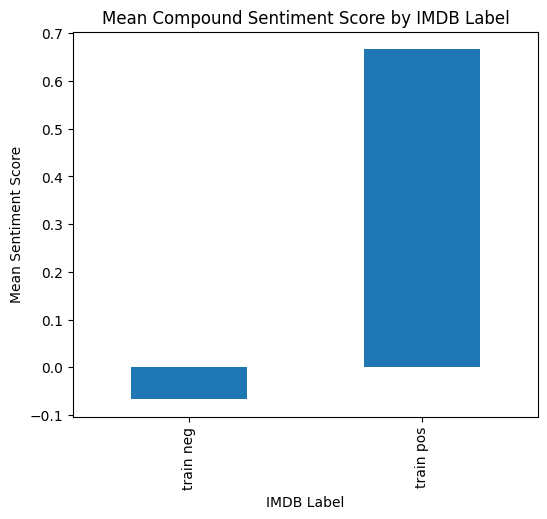

In [13]:
# Generate mean compound sentiment by IMDB label
dfg = df_output.groupby('label')['sentiment_score'].mean()

# Create a bar plot
dfg.plot(
    kind='bar',
    title='Mean Compound Sentiment Score by IMDB Label',
    ylabel='Mean Sentiment Score',
    xlabel='IMDB Label',
    figsize=(6, 5)
)

plt.show()


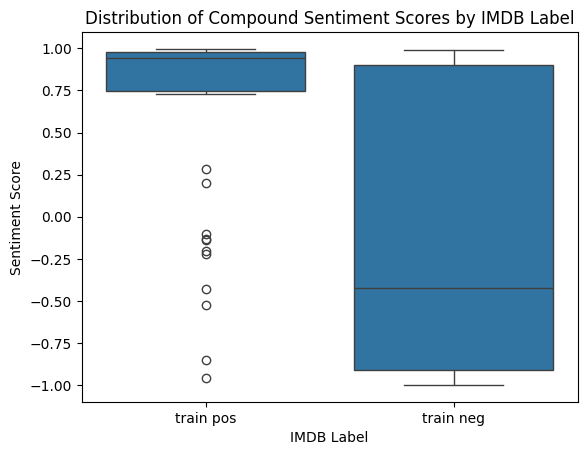

In [15]:
import seaborn as sns

sns.boxplot(
    data=df_output,
    x='label',
    y='sentiment_score'
)

plt.title('Distribution of Compound Sentiment Scores by IMDB Label')
plt.xlabel('IMDB Label')
plt.ylabel('Sentiment Score')
plt.show()


In [16]:
import altair as alt

# Prepare data: mean sentiment by label
dfg_label = (
    df_output
    .groupby('label')['sentiment_score']
    .mean()
    .reset_index()
)

# Altair bar chart
chart_label = alt.Chart(dfg_label).mark_bar().encode(
    x=alt.X('label:N', title='IMDB Label'),
    y=alt.Y('sentiment_score:Q', title='Mean Compound Sentiment Score'),
    color=alt.Color('label:N', legend=None),
    tooltip=['label', 'sentiment_score']
).properties(
    title='Mean Compound Sentiment Score by IMDB Label'
)

chart_label


alt.Chart(...)

In [17]:
chart_hist = alt.Chart(df_output).mark_bar().encode(
    x=alt.X(
        'sentiment_score:Q',
        bin=alt.Bin(maxbins=30),
        title='Compound Sentiment Score'
    ),
    y=alt.Y('count():Q', title='Frequency'),
    tooltip=['count()']
).properties(
    title='Distribution of Compound Sentiment Scores'
)

chart_hist


alt.Chart(...)

# Visualize and explain your sentiment results using two different visualization libraries.

In the first plot, I used pandas and matplotlib. The second is seaborn, and the next two are altair for interactivity. From the plots wwe can see that the analysis heavily skew towards positivity. Not only are there more positive results, the positive results are closer to 1, than the negative results are to -1 which we can tell explicitly from the mean compound score where the positive reviews have a mean sentiment score of 0.66 and the negative having a mean of -0.067.

# Reflection
It was a bit difficult figuring out how I could workshop the code and text files from lab-4 here, but honestly after figuring out the first part of creating the datafram, everything was the same. It is a little dissapointing, I don't have as cool graphs as the example that you used in your example since it had year or providence. However seeing the last chart tellm me this lab was succesful and that the IMBD reviews contain very strong, emotional, and sentimental language. Positive reviews tend to be extremely postivive, and same goes for the negative reviews. Reviews tend to not be neutral. Why would you write a review otherwise. Reviews that are factual and unemotions likely do not exist in the real world. From our discussions and readings, we learning that sentiment analysis isn't always correct and that sentiment can either reverse the polarity or heavily skew the results as positive. I'm not sure if that applies exactly to VADAR, but in the data we see a skew leaning heavily towards positive reviews dispite there being an even amount originaly. I did some code below to see how accurate VADAR was and it got a 69% accuracy score. At least it got the top extremely positive and negative reviews correct. This makes me think that I should have chosen the pro stance instead of the critic stance since it is still accurate. Or maybe VADAR is just more advanced and accurate than the models used in the readings. In my future profession, I can use sentiment analysis to analyze tweets, reviews, or commments about the places I work. I am currently applying to jobs in museums, so I could use it to analyze text about the art in the museum to see what the most popular pieces are, most popular artist, or to see what people think of the museum or museums. I can see sentiment analisis is used on tweets since they don't have a rating system like yelp or google reviews. Other applications besides tweets are in reddit or other discussion forums.

In [20]:

df_output['predicted_label'] = df_output['sentiment_score'].apply(
    lambda x: 'train pos' if x > 0 else 'train neg'
)

accuracy = (df_output['label'] == df_output['predicted_label']).mean()
accuracy


np.float64(0.69)